In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# 让 matplotlib 图形在 notebook 中显示
%matplotlib inline

 读取并探索数据

In [109]:
# 读取 CSV
df = pd.read_csv('data.csv')

# 删除因第一行末尾多余逗号而自动生成的 'Unnamed: 32' 列（如果存在）
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# 查看数据形状和列名
print("数据形状:", df.shape)          # 应输出 (569, 32)
print("列名:", df.columns.tolist())

# 去掉 'id' 列（不参与训练）
df.drop('id', axis=1, inplace=True)

# 将 diagnosis 转换为数字：B -> 0, M -> 1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# 检查是否有缺失值（现在应该没有）
print("缺失值总数:", df.isnull().sum().sum())   # 应为 0

数据形状: (569, 32)
列名: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
缺失值总数: 0


数据预处理

In [110]:
# 特征和标签
X = df.drop('diagnosis', axis=1).values.astype(np.float32)
y = df['diagnosis'].values.astype(np.int64)

# 划分（20% 测试集，保持类别比例）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

训练集大小: (455, 30), 测试集大小: (114, 30)


In [111]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 确认无 NaN
print("训练集是否有 NaN:", np.isnan(X_train_scaled).any())
print("测试集是否有 NaN:", np.isnan(X_test_scaled).any())

训练集是否有 NaN: False
测试集是否有 NaN: False


In [112]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

搭建MLP模型

In [113]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, output_dim=2):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)  # 防止过拟合

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)   # 不用 softmax，因为 CrossEntropyLoss 会帮我们计算
        return x

# 实例化模型
input_dim = X_train_scaled.shape[1]
model = MLP(input_dim)
print(model)

MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


训练模型

In [114]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # 每 10 个 epoch 在测试集上评估一次
    if (epoch+1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            outputs_test = model(X_test_tensor)
            _, predicted = torch.max(outputs_test, 1)
            acc = accuracy_score(y_test, predicted.numpy())
            test_accuracies.append(acc)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Test Acc: {acc:.4f}')

Epoch [10/100], Loss: 0.0617, Test Acc: 0.9825
Epoch [20/100], Loss: 0.0324, Test Acc: 0.9737
Epoch [30/100], Loss: 0.0183, Test Acc: 0.9737
Epoch [40/100], Loss: 0.0114, Test Acc: 0.9737
Epoch [50/100], Loss: 0.0132, Test Acc: 0.9737
Epoch [60/100], Loss: 0.0050, Test Acc: 0.9737
Epoch [70/100], Loss: 0.0028, Test Acc: 0.9737
Epoch [80/100], Loss: 0.0038, Test Acc: 0.9737
Epoch [90/100], Loss: 0.0020, Test Acc: 0.9737
Epoch [100/100], Loss: 0.0013, Test Acc: 0.9737


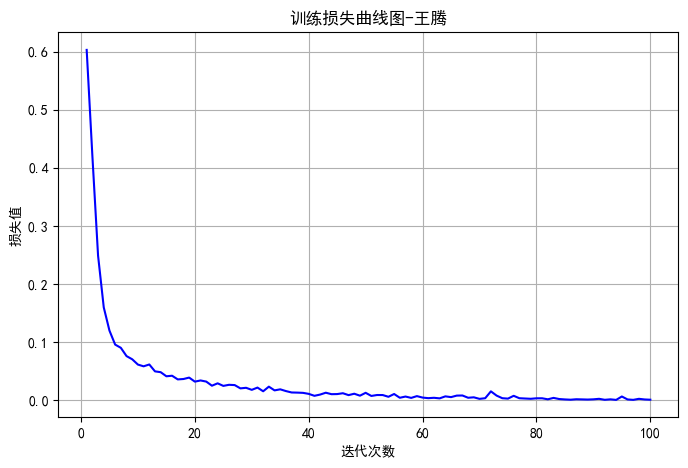

In [115]:


import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']   
plt.rcParams['axes.unicode_minus'] = False

# 然后绘制损失曲线
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, 'b-')
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.title('训练损失曲线图-王腾')  
plt.grid(True)
plt.show()

测试集最终评估与混淆矩阵

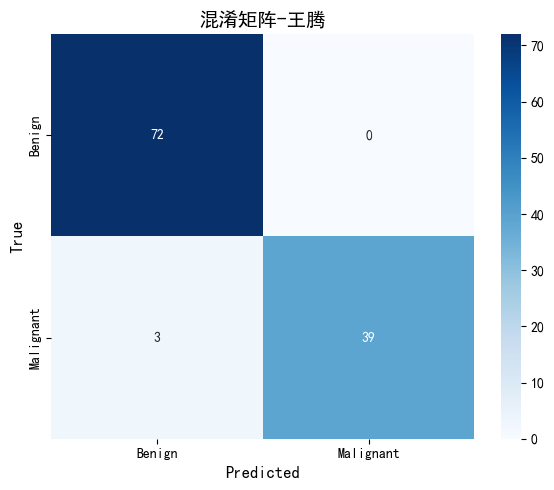

In [116]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    _, y_pred_class = torch.max(y_pred, 1)
    y_pred_class = y_pred_class.numpy()

cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('混淆矩阵-王腾', fontsize=14)   
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

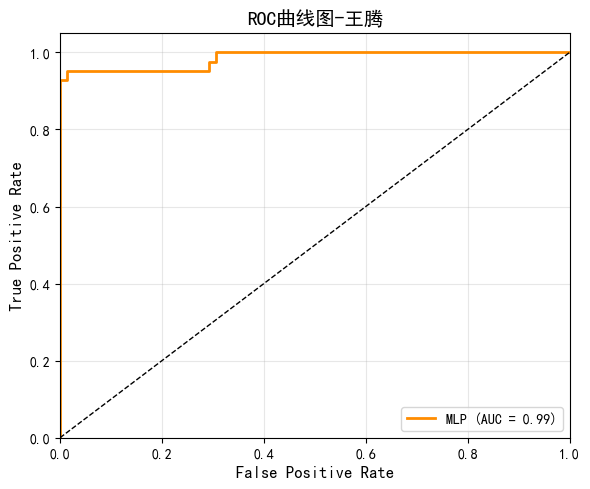

In [117]:

from sklearn.metrics import roc_curve, auc

model.eval()
with torch.no_grad():
    y_probs = torch.softmax(model(X_test_tensor), dim=1)[:, 1].numpy()

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'MLP (AUC = {roc_auc:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC曲线图-王腾', fontsize=14)  
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

与其他模型比较

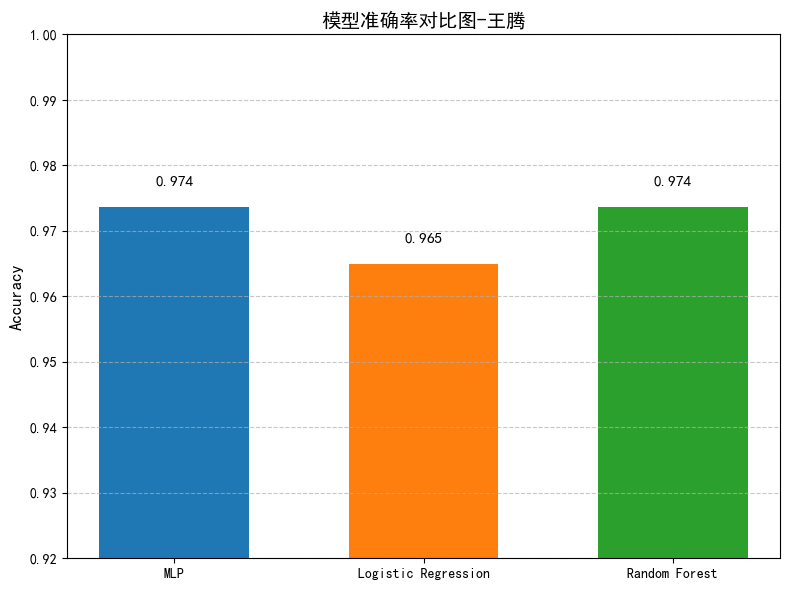

In [118]:
# 模型对比柱状图 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 训练对比模型
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

# 获取 MLP 准确率（假设您已经训练好并计算过）
acc_mlp = accuracy_score(y_test, y_pred_class)   # y_pred_class 来自上一步混淆矩阵代码

models = ['MLP', 'Logistic Regression', 'Random Forest']
accuracies = [acc_mlp, acc_lr, acc_rf]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.6)
plt.ylim(0.92, 1.0)
plt.ylabel('Accuracy', fontsize=12)
plt.title('模型准确率对比图-王腾', fontsize=14)   
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()